# Práctica 3 – GLMs en Pricing de Autos (Python)

**Objetivo:** Simular una cartera (autos como ejemplo), explorar los datos, ajustar modelos GLM de **frecuencia** y **severidad**, calcular la **prima pura** por póliza y evaluar la segmentación (**Gini**) y la interpretabilidad (**PDPs**).  

En este cuaderno aprenderás a modelar la frecuencia y severidad de siniestros para un portafolio de autos usando Modelos Lineales Generalizados (GLMs).

*Nota:* Los comentarios y conclusiones  incluyen fórmulas para justificar las decisiones de modelado. Las referencias teóricas se basan en datos de seguros reales.


## Paso 0 – Simulación de una cartera de autos

Antes de usar datos reales, generaremos una cartera sintética para replicar la práctica. Supondremos que cada póliza tiene una **exposición** (en años), características del conductor y del vehículo, y un número de siniestros y monto de reclamaciones generado a partir de distribuciones paramétricas.

1. **Características de riesgo**: simularemos la edad del conductor (`DrivAge`), la antigüedad del vehículo (`VehAge`), la potencia (`VehPower`) y el tipo de área (`Area`).
2. **Frecuencia**: supondremos que el número de siniestros `N` sigue una distribución Poisson con media 
   
   $$
   \lambda_i = \exp(\beta_0 + \beta_1 \, \text{Age}_i + \beta_2 \, \text{VehAge}_i + \beta_3 \, \text{Area}_i) 	\times \text{Exposure}_i
   $$

3. **Severidad**: si una póliza tiene siniestros (`N > 0`), cada siniestro tiene un importe generado de una distribución Gamma con forma y escala fijas.  La severidad media por póliza se calcula como `ClaimAmount / N`.

El siguiente código crea un DataFrame simulando 10,000 pólizas conforme a estas hipótesis.


## Explicación del Paso 0 – Simulación

En la celda de simulación generamos un conjunto de 10 000 pólizas sintéticas. A continuación se explica cada línea de código:
- **Generador de números aleatorios (`np.random.default_rng`)**: se crea un generador moderno con semilla fija (`seed=42`). Utilizar una semilla permite reproducir la simulación.


En esta celda importamos las bibliotecas **NumPy** y **Pandas** y definimos el número de pólizas `n` junto con el generador de números aleatorios `rng`. La semilla fija garantiza que la simulación sea reproducible.

In [1]:
import numpy as np
import pandas as pd

# Número de pólizas a simular
n = 10000
rng = np.random.default_rng(seed=42)



Se han definido las variables básicas: `n` es el tamaño de la cartera y `rng` es el generador aleatorio. Estos se utilizarán para simular la exposición, características de riesgo y siniestros.

Simulamos la **exposición** de cada póliza. La exposición representa la fracción del año durante la cual la póliza está vigente, por lo que se genera de manera uniforme entre 0.5 y 1.0.

In [2]:

# Exposición (entre 0.5 y 1 año)
Exposure = rng.uniform(0.5, 1.0, size=n)

# Variables de riesgo
DrivAge = rng.integers(18, 75, size=n)
VehAge  = rng.integers(0, 20, size=n)
VehPower = rng.integers(4, 13, size=n)  # categorías 4–12
Area = rng.choice(list('ABCDEF'), size=n, p=[0.2, 0.2, 0.2, 0.15, 0.15, 0.1])



Se obtuvo un vector `Exposure` con valores continuos entre 0.5 y 1.0. Cada póliza estará vigente al menos medio año y como máximo un año completo.


- **Coeficientes del modelo de frecuencia**: asignamos valores arbitrarios (`beta0`, `beta_age`, `beta_veh`, `beta_area`) que controlan la relación entre cada variable y el logaritmo de la tasa de siniestros.
- **Tasa de siniestros (`mu_freq`)**: calculamos el predictor lineal `eta` y lo transformamos con `np.exp(eta)` para obtener un valor positivo. Multiplicamos por la exposición para obtener el número esperado de siniestros por póliza.
-  **Número de siniestros**: `rng.poisson(lam=mu_freq)` genera conteos de siniestros siguiendo una distribución Poisson.

Definimos los **coeficientes del modelo de frecuencia**: un intercepto (`beta0`), un efecto de la edad del conductor (`beta_age`), un efecto de la antigüedad del vehículo (`beta_veh`) y una tabla con los efectos por área (`beta_area`).

In [3]:
# Coeficientes para el modelo Poisson de frecuencia
beta0 = -3.0
beta_age = 0.015   # incremento por cada año del conductor
beta_veh = -0.02  # vehículos viejos tienen menos siniestros
beta_area = { 'A':0.0, 'B':0.1, 'C':0.2, 'D':0.3, 'E':0.4, 'F':0.5 }

# Tasa de siniestros
eta = (beta0 + beta_age*DrivAge + beta_veh*VehAge
       + np.array([beta_area[a] for a in Area]))
lam = np.exp(eta)
mu_freq = lam * Exposure
N = rng.poisson(mu_freq)



Estos parámetros determinan la relación logarítmica entre las covariables y la tasa de siniestros 
$$
\lambda_i = \exp(\beta_i)\,	\text{Exposure}_i
$$ 

Por ejemplo, `beta_age = 0.015` implica un aumento relativo de \(e^{0.015}≈1.015\) veces la frecuencia por cada año adicional del conductor.

- **Severidad**: para las pólizas con al menos un siniestro (`N>0`).

$$
Y_{ij}\mid N_i>0 \sim \text{Gamma}(\mu_i,\phi),\quad \log\mu_i = \alpha_0 + \alpha_1\,\text{VehPower}_i + \sum_k \alpha_k^{(Area)}\,\mathbf{1}\{Area=k\}
$$

In [4]:
alpha0, a_power = 8.0, 0.03
alpha_area = {'A':0,'B':0.02,'C':0.06,'D':0.08,'E':0.12,'F':0.15}
phi = 1.5  # parámetro de dispersión Gamma (forma ~ 1/phi)

sev_mu = np.exp(alpha0 + a_power*VehPower + np.array([alpha_area[a] for a in Area]))

# Generar severidades por póliza: suma por póliza
claim_amount = np.zeros(n)
for i in range(n):
    if N[i] > 0:
        y = rng.gamma(shape=1/phi, scale=sev_mu[i]*phi, size=N[i])
        claim_amount[i] = y.sum()




Este paso te permite experimentar con los parámetros y entender cómo influyen en la frecuencia y severidad. Cuando utilices una cartera real, sustituye esta simulación por la carga de tus propios datos (por ejemplo, con `pandas.read_csv`).

Construimos un **DataFrame** con todas las variables simuladas: identificador de póliza, exposición, variables de riesgo, número de siniestros y montos de reclamación.

In [5]:
# DataFrame simulado
df = pd.DataFrame({
    'IDpol': np.arange(1, n+1),
    'Exposure': Exposure,
    'DrivAge': DrivAge,
    'VehAge': VehAge,
    'VehPower': VehPower,
    'Area': Area,
    'ClaimNb': N,
    'ClaimAmount':claim_amount
})

# Mostramos las primeras filas
df.head()

,IDpol,Exposure,DrivAge,VehAge,VehPower,Area,ClaimNb,ClaimAmount
0,1,0.886978,19,4,12,F,0,0.0
1,2,0.719439,59,6,10,F,0,0.0
2,3,0.929299,30,17,5,E,0,0.0
3,4,0.848684,58,2,12,C,0,0.0
4,5,0.547089,50,2,12,C,0,0.0


El DataFrame `df` resultante contiene toda la información necesaria para ajustar los modelos de frecuencia y severidad en los pasos siguientes.

**Qué observar**  
- Tasa bruta $\widehat{rate} = \sum N_i / \sum Exposure_i$ 
- Severidad bruta $\widehat{\mu} = \sum ClaimAmount / \sum N_i$ (solo pólizas con $N_i>0$)  
- Signos esperados: `DrivAge` positivo en frecuencia, `VehAge` negativo; `Area` creciente.
- Gráficas sugeridas: hist de `ClaimNb`, barras de exposición por `Area`, densidad/box de severidad (solo `ClaimNb>0`).  


## Paso 1 · EDA (tasa y severidad)

**Qué haremos**  
Exploraremos **exposición**, **frecuencia** y **severidad** por variables clave. Crearemos bandas para continuas y usaremos IC aproximados para tasas.

**Fórmulas**  
Tasa por grupo g: 
$$
\widehat{rate}_g = \frac{\sum_{i\in g} N_i}{\sum_{i\in g} Exposure_i}
$$

Severidad promedio: 
$$
\widehat{\mu}_g = \frac{\sum_{i\in g} ClaimAmount_i}{\sum_{i\in g} N_i}\
$$ 
si $\sum N_i>0$

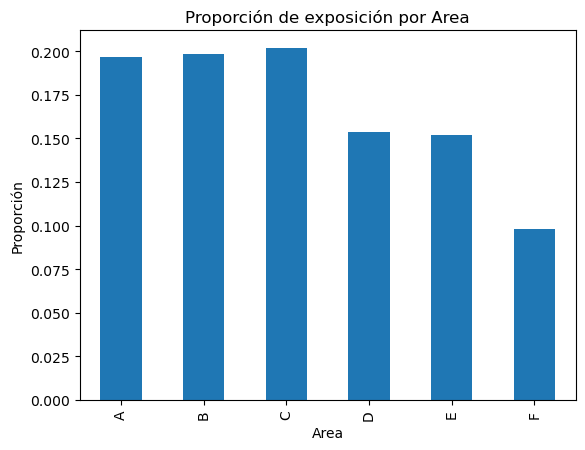

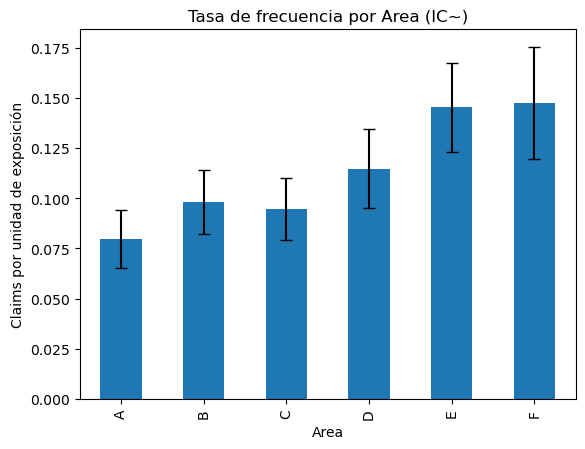

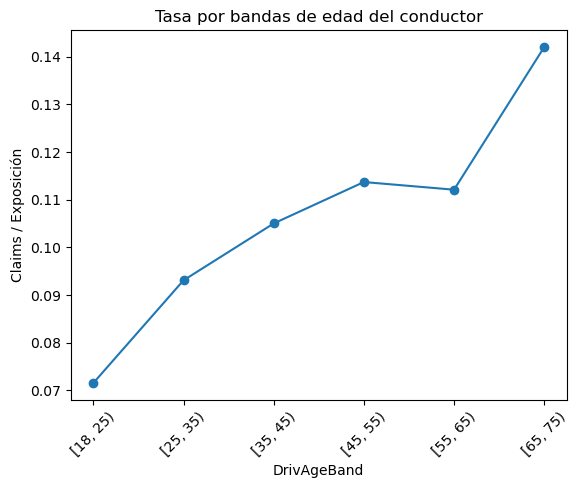

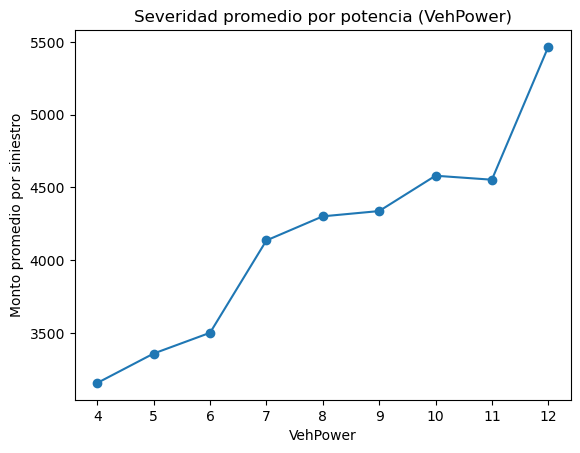

In [6]:

import numpy as np, pandas as pd
import matplotlib.pyplot as plt


# Barras de exposición por Area
expo_by_area = df.groupby("Area", observed=True)["Exposure"].sum().rename("Expo")
(expo_by_area / expo_by_area.sum()).plot(kind="bar")
plt.title("Proporción de exposición por Area")
plt.ylabel("Proporción")
plt.show()

# Tasa por Area con IC aproximado
g = df.groupby("Area", observed=True).agg(Claims=("ClaimNb","sum"),
                                          Expo=("Exposure","sum"))
g["rate"] = g["Claims"]/g["Expo"]
g["se_rate"] = np.sqrt(g["rate"]*(1/np.maximum(g["Expo"],1e-9)))
ax = g["rate"].plot(kind="bar", yerr=1.96*g["se_rate"], capsize=4)
plt.title("Tasa de frecuencia por Area (IC~)")
plt.ylabel("Claims por unidad de exposición")
plt.show()

# Bands de DrivAge
bins = np.r_[18,25,35,45,55,65,75]
df["DrivAgeBand"] = pd.cut(df["DrivAge"], bins=bins, right=False)
rate_age = df.groupby("DrivAgeBand", observed=True).apply(
    lambda t: t["ClaimNb"].sum()/t["Exposure"].sum()
)
rate_age.plot(marker="o")
plt.title("Tasa por bandas de edad del conductor")
plt.ylabel("Claims / Exposición")
plt.xticks(rotation=45)
plt.show()

# Severidad por VehPower (solo con siniestro)
pos = df["ClaimNb"]>0
sev_pw = (df.loc[pos]
          .groupby("VehPower")["ClaimAmount"].sum()
         /df.loc[pos].groupby("VehPower")["ClaimNb"].sum())
sev_pw.plot(marker="o")
plt.title("Severidad promedio por potencia (VehPower)")
plt.ylabel("Monto promedio por siniestro")
plt.show()


**Interpretación**  
- Si la tasa aumenta en bandas jóvenes de `DrivAge`, es consistente con $\beta_1>0$.  
- `Area` escalonado en tasa/ severidad es coherente con los parámetros simulados.  
- En severidad, crecimiento con `VehPower` apoya $\alpha_1>0$.  


## Paso 2 – Modelado de la frecuencia

La **frecuencia** se define como el número de siniestros por unidad de exposición: 

$$\text{Frequency}_i = \frac{\text{ClaimNb}_i}{\text{Exposure}_i}$$



Importamos las bibliotecas de **Statsmodels** y preparamos los datos para el modelado. Copiamos el DataFrame simulado y convertimos las variables categóricas (`Area` y `VehPower`) en factores para que Patsy las trate adecuadamente.

In [7]:
import statsmodels.api as sm
import statsmodels.formula.api as smf


# Convertimos las variables categóricas
for col in ['Area', 'VehPower']:
    df[col] = df[col].astype('category')


# Categórica con orden y referencia
df["Area"] = df["Area"].cat.reorder_categories(list("ABCDEF"))

df.head()

,IDpol,Exposure,DrivAge,VehAge,VehPower,Area,ClaimNb,ClaimAmount,DrivAgeBand
0,1,0.886978,19,4,12,F,0,0.0,"[18, 25)"
1,2,0.719439,59,6,10,F,0,0.0,"[55, 65)"
2,3,0.929299,30,17,5,E,0,0.0,"[25, 35)"
3,4,0.848684,58,2,12,C,0,0.0,"[55, 65)"
4,5,0.547089,50,2,12,C,0,0.0,"[45, 55)"


Con el DataFrame `df` preparado y las variables categóricas convertidas en factores, estamos listos para especificar la fórmula del modelo de frecuencia.

Definimos la **fórmula del modelo de frecuencia** usando la sintaxis de Patsy. La respuesta es `ClaimNb` y las covariables son `VehPower`, `VehAge`, `DrivAge` y `Area`.

In [8]:

formula = "ClaimNb ~ DrivAge + VehAge + C(Area, Treatment(reference='A'))"


La fórmula `ClaimNb ~ C(VehPower) + VehAge + DrivAge + C(Area)` indica que la frecuencia se modelará como función lineal de las covariables con tratamiento adecuado de las variables categóricas mediante `C(...)`, ye ñligiendo el valor de referencia mediante `Treatment(reference=...)` para evitar la trampa de la variable ficticia.

Ajustamos un **Modelo Lineal Generalizado Poisson** con enlace log. Se especifica la familia `Poisson` y se incluye `np.log(df['Exposure'])` como offset para tener en cuenta la exposición de cada póliza.


$$
N_i \sim \text{Poisson}(\mu_i),\quad \log \mu_i = \log(Exposure_i) + X_i\beta
$$ 

In [9]:
# Modelo Poisson
model_pois = smf.glm(formula=formula, data=df,
                     family=sm.families.Poisson(),
                     offset=np.log(df['Exposure'])).fit()

print(model_pois.summary())



                 Generalized Linear Model Regression Results                  
Dep. Variable:                ClaimNb   No. Observations:                10000
Model:                            GLM   Df Residuals:                     9992
Model Family:                 Poisson   Df Model:                            7
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -2822.9
Date:                Wed, 01 Oct 2025   Deviance:                       4070.9
Time:                        15:55:02   Pearson chi2:                 9.92e+03
No. Iterations:                     6   Pseudo R-squ. (CS):           0.007255
Covariance Type:            nonrobust                                         
                                             coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------

Este modelo estima los parámetros $\beta$ de la ecuación:

$$
\log(\mathbb{E}[\text{ClaimNb}_i]) = \log(\text{Exposure}_i) + \beta_0 + \beta_1\, \text{VehPower}_i + \beta_2\,\text{VehAge}_i + \beta_3\,	\text{DrivAge}_i + \beta_4\,	\text{Area}_i.
$$

Se pueden comparar los coeficientes estimados con los valores utilizados en la simulación para validar el modelo.

$e^{\beta_j}$ es el **multiplicador** de tasa vs. la categoría de referencia.  


Calculamos las **medidas de sobredispersión**: la relación varianza/media y la relación deviance/df. Estas estadísticas ayudan a diagnosticar si la distribución Poisson es adecuada.

In [10]:
# Medidas de sobredispersión
freq = df['ClaimNb'] / df['Exposure']
dispersion_ratio = freq.var() / freq.mean()
deviance_ratio = model_pois.deviance / model_pois.df_resid
print(f"Varianza/Media: {dispersion_ratio:.2f}")
print(f"Deviance/df: {deviance_ratio:.2f}")



Varianza/Media: 1.40
Deviance/df: 0.41


Si la relación varianza/media es mayor que 1, existe sobredispersión y el modelo Poisson puede ser inadecuado. En ese caso consideraríamos una Binomial Negativa.

Si `Deviance/df` es grande y NegBin mejora sustancialmente AIC/Dev, preferir NegBin.  

Ajustamos un **modelo Binomial Negativa** (NegativeBinomial) para la frecuencia. Este modelo introduce un parámetro de dispersión extra para manejar la sobredispersión.

In [11]:
# Modelo Binomial Negativa
model_nb = smf.glm(formula=formula, data=df,
                   family=sm.families.NegativeBinomial(),
                   offset=np.log(df['Exposure'])).fit()


print(model_nb.summary())


                 Generalized Linear Model Regression Results                  
Dep. Variable:                ClaimNb   No. Observations:                10000
Model:                            GLM   Df Residuals:                     9992
Model Family:        NegativeBinomial   Df Model:                            7
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -2835.1
Date:                Wed, 01 Oct 2025   Deviance:                       3480.4
Time:                        15:55:15   Pearson chi2:                 9.18e+03
No. Iterations:                     5   Pseudo R-squ. (CS):           0.006690
Covariance Type:            nonrobust                                         
                                             coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------

c:\Users\Eric_Daniel\anaconda3\envs\6.86x\lib\site-packages\statsmodels\genmod\families\family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


Imprimimos los valores del **AIC** para los modelos Poisson y Binomial Negativa.

In [12]:
print("AIC Poisson vs NB:", model_pois.aic, model_nb.aic)


AIC Poisson vs NB: 5661.799231030633 5686.291757590181


El modelo con el AIC más bajo se considera preferible; en la simulación es probable que el Poisson tenga un AIC ligeramente menor debido a la forma en que se generaron los datos.

## Paso 2 – Modelado de la severidad

La **severidad** corresponde al monto promedio por siniestro: 
 

$$
\text{Severity}_i = \frac{\text{ClaimAmount}_i}{\max\{\text{ClaimNb}_i, 1\}}
$$

Según la teoría actuarial, la severidad suele seguir una distribución Gamma con enlace log. Filtramos las pólizas con montos positivos y utilizamos el número de siniestros como peso para reflejar que una póliza con varios reclamos aporta más información.



Filtramos el DataFrame para quedarnos con las pólizas que tienen montos de reclamación positivos y calculamos la **severidad** como `ClaimAmount/ClaimNb`.

In [13]:
# Filtramos pólizas con monto positivo
sev = df[df['ClaimAmount'] > 0].copy()
sev['Severity'] = sev['ClaimAmount'] / sev['ClaimNb']

sev.head()


,IDpol,Exposure,DrivAge,VehAge,VehPower,Area,ClaimNb,ClaimAmount,DrivAgeBand,Severity
6,7,0.880570,44,12,4,A,1,2080.676522,"[35, 45)",2080.676522
26,27,0.733361,23,4,10,E,1,7665.823869,"[18, 25)",7665.823869
32,33,0.662913,74,15,11,D,1,1636.413145,"[65, 75)",1636.413145
39,40,0.834907,59,6,9,A,1,3277.591241,"[55, 65)",3277.591241
41,42,0.916339,27,17,11,B,1,21001.611649,"[25, 35)",21001.611649


La nueva tabla `sev` contiene únicamente las pólizas con siniestros y una columna `Severity` que representa el coste medio por siniestro.

Filtramos el DataFrame para quedarnos con las pólizas que tienen montos de reclamación positivos y calculamos la **severidad** como `ClaimAmount/ClaimNb`.

In [14]:
formula_sev = 'Severity ~ C(VehPower) + VehAge + DrivAge + C(Area)'

In [15]:
# Modelo Gamma
model_gamma = smf.glm(formula=formula_sev, data=sev,
                      family=sm.families.Gamma(link=sm.families.links.log()),
                      weights=sev['ClaimNb']).fit()
print(model_gamma.summary())


                 Generalized Linear Model Regression Results                  
Dep. Variable:               Severity   No. Observations:                  777
Model:                            GLM   Df Residuals:                      761
Model Family:                   Gamma   Df Model:                           15
Link Function:                    log   Scale:                          1.3249
Method:                          IRLS   Log-Likelihood:                -7208.5
Date:                Wed, 01 Oct 2025   Deviance:                       1270.5
Time:                        15:55:29   Pearson chi2:                 1.01e+03
No. Iterations:                    15   Pseudo R-squ. (CS):            0.03651
Covariance Type:            nonrobust                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept             7.7906      0.21

c:\Users\Eric_Daniel\anaconda3\envs\6.86x\lib\site-packages\statsmodels\genmod\families\links.py:13: FutureWarning: The log link alias is deprecated. Use Log instead. The log link alias will be removed after the 0.15.0 release.
  warnings.warn(
c:\Users\Eric_Daniel\anaconda3\envs\6.86x\lib\site-packages\statsmodels\base\model.py:130: ValueWarning: unknown kwargs ['weights']
  warnings.warn(msg, ValueWarning)


In [16]:
# Tratamiento de siniestros grandes: percentil 95
threshold = sev['ClaimAmount'].quantile(0.95)
sev_trim = sev[sev['ClaimAmount'] <= threshold]

model_gamma_trim = smf.glm(formula=formula_sev, data=sev_trim,
                           family=sm.families.Gamma(link=sm.families.links.log()),
                           weights=sev_trim['ClaimNb']).fit()

print("Umbral del 95 % para grandes siniestros:", threshold)

print(model_gamma_trim.summary())

Umbral del 95 % para grandes siniestros: 14650.515499966235
                 Generalized Linear Model Regression Results                  
Dep. Variable:               Severity   No. Observations:                  738
Model:                            GLM   Df Residuals:                      722
Model Family:                   Gamma   Df Model:                           15
Link Function:                    log   Scale:                          1.0323
Method:                          IRLS   Log-Likelihood:                -6724.9
Date:                Wed, 01 Oct 2025   Deviance:                       1099.4
Time:                        15:55:34   Pearson chi2:                     745.
No. Iterations:                    14   Pseudo R-squ. (CS):            0.02049
Covariance Type:            nonrobust                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------

c:\Users\Eric_Daniel\anaconda3\envs\6.86x\lib\site-packages\statsmodels\genmod\families\links.py:13: FutureWarning: The log link alias is deprecated. Use Log instead. The log link alias will be removed after the 0.15.0 release.
  warnings.warn(
c:\Users\Eric_Daniel\anaconda3\envs\6.86x\lib\site-packages\statsmodels\base\model.py:130: ValueWarning: unknown kwargs ['weights']
  warnings.warn(msg, ValueWarning)


En la siguiente celda ajustaremos una **distribución Weibull** a la severidad para contrastar con el modelo Gamma. Usaremos `scipy.stats.weibull_min.fit()` fijando el parámetro de ubicación en 0.

In [17]:
from scipy.stats import weibull_min
# Ajuste de la distribución Weibull a la severidad
sev_values = sev['Severity'].values
shape_weib, loc_weib, scale_weib = weibull_min.fit(sev_values, floc=0)
print('Parámetros Weibull: shape={:.3f}, scale={:.1f}'.format(shape_weib, scale_weib))
weibull_mean = weibull_min.mean(shape_weib, loc_weib, scale_weib)
print('Severidad media estimada (Weibull):', weibull_mean)
# Predicción de severidad constante para cada póliza
sev_pred_weibull = np.full(len(df), weibull_mean)

Parámetros Weibull: shape=0.806, scale=3717.0
Severidad media estimada (Weibull): 4188.991560891297


El ajuste de la Weibull produce parámetros de forma y escala que resumen la distribución de la severidad simulada. Dado que la Weibull no incorpora covariables, la severidad predicha es constante para todas las pólizas. La comparación entre la media Gamma y la media Weibull ayuda a evaluar la adecuación de las distribuciones.

Comparamos el AIC del modelo Gamma completo y el recortado.

In [18]:
print("AIC modelo completo vs recortado:", model_gamma.aic, model_gamma_trim.aic)

AIC modelo completo vs recortado: 14448.97301598435 13481.892153900732


El modelo con menor AIC indica un equilibrio entre ajuste y complejidad. Si el recortado tiene un AIC menor, es preferible para la severidad.

## Paso 3 – Cálculo de la prima pura

Una vez ajustados los modelos de frecuencia y severidad, la prima pura esperada para cada póliza se calcula como el producto de las predicciones de frecuencia y severidad:

$$
\pi_i = \hat{\lambda}_i \times \hat{\mu}_i
$$

A continuación combinamos las estimaciones de frecuencia (usando el modelo Binomial Negativa si hay sobredispersión) y de severidad para obtener la prima pura predicha.


Calculamos las **predicciones** de frecuencia y severidad para cada póliza y obtenemos la prima pura predicha como el producto de ambas.

In [19]:
# Predicciones de frecuencia y severidad
freq_pred = model_nb.predict(df, offset=np.log(df['Exposure']))
sev_pred  = model_gamma.predict(df)

# Prima pura predicha
pure_premium_pred = freq_pred * sev_pred

# Añadimos al DataFrame
result = df.copy()
result['PurePremium_pred'] = pure_premium_pred

result.head()


,IDpol,Exposure,DrivAge,VehAge,VehPower,Area,ClaimNb,ClaimAmount,DrivAgeBand,PurePremium_pred
0,1,0.886978,19,4,12,F,0,0.0,"[18, 25)",613.453873
1,2,0.719439,59,6,10,F,0,0.0,"[55, 65)",651.953566
2,3,0.929299,30,17,5,E,0,0.0,"[25, 35)",428.607543
3,4,0.848684,58,2,12,C,0,0.0,"[55, 65)",462.891246
4,5,0.547089,50,2,12,C,0,0.0,"[45, 55)",273.005714


comparamos por segmentos (por ejemplo, bandas de edad del conductor y tipo de área).

In [20]:
# Segmentación por bandas de edad y área
result['AgeBand'] = pd.cut(result['DrivAge'], bins=[18,30,45,60,75,100], include_lowest=True)
grouped = result.groupby(['AgeBand','Area']).agg(
    expo=('Exposure','sum'),
    n=('IDpol','count'),
    pure_premium_pred=('PurePremium_pred','mean')
).reset_index()

grouped.head()

,AgeBand,Area,expo,n,pure_premium_pred
0,"(17.999, 30.0]",A,315.626651,425,150.911240
1,"(17.999, 30.0]",B,368.015975,490,216.888285
2,"(17.999, 30.0]",C,329.259715,437,211.378541
3,"(17.999, 30.0]",D,284.653644,379,308.850110
4,"(17.999, 30.0]",E,248.210936,325,402.551161


A continuación calcularemos la **prima pura por póliza**, evaluaremos el **índice de Gini** para medir la discriminación del modelo y obtendremos predicciones parciales de la prima pura en función de la edad del conductor.

In [21]:
# Prima pura y evaluación de discriminación
freq_pred_full = model_nb.predict(df, offset=np.log(df['Exposure']))
sev_pred_full = model_gamma.predict(df)
# Prima pura por póliza
pure_premium_pred_full = freq_pred_full * sev_pred_full
df['PurePremium'] = pure_premium_pred_full
print(df[['IDpol','PurePremium']].head())
# Índice de Gini para la prima pura
import numpy as np
def gini(actual, pred):
    arr = np.c_[actual, pred, np.arange(len(actual))]
    order = arr[:,1].argsort()
    arr = arr[order]
    total = arr[:,0].sum()
    cum_actual = np.cumsum(arr[:,0])
    gini_sum = cum_actual.sum() / total
    gini_sum -= (len(actual)+1)/2.0
    return gini_sum / len(actual)
actual_cost_per_exposure = df['ClaimAmount'] / df['Exposure']
gini_pure = gini(actual_cost_per_exposure.values, pure_premium_pred_full)
print('Índice de Gini para la prima pura:', gini_pure)



   IDpol  PurePremium
0      1   613.453873
1      2   651.953566
2      3   428.607543
3      4   462.891246
4      5   273.005714
Índice de Gini para la prima pura: -0.10647050770814721


La tabla de primas puras muestra el coste esperado por póliza obtenido como producto de la frecuencia y la severidad predichas. El **índice de Gini** calculado compara la clasificación de las pólizas según la prima pura con el coste real por exposición; un valor más alto indica mejor discriminación del modelo.



In [22]:
# Predicciones parciales de la prima pura según la edad del conductor
age_grid = np.arange(18, 76, 10)
partial_df = pd.DataFrame({
    'DrivAge': age_grid,
    'VehAge': [df['VehAge'].median()] * len(age_grid),
    'VehPower': [df['VehPower'].cat.categories[0]] * len(age_grid),
    'Area': [df['Area'].cat.categories[0]] * len(age_grid),
    'Exposure': [1.0] * len(age_grid)
})
partial_df['VehPower'] = partial_df['VehPower'].astype(df['VehPower'].dtype)
partial_df['Area'] = partial_df['Area'].astype(df['Area'].dtype)
# Frecuencia parcial con modelo NB
partial_freq = model_nb.predict(partial_df, offset=np.log(partial_df['Exposure']))
# Severidad media con Gamma (para simplificar usamos la media Weibull)
partial_pure = partial_freq * weibull_mean
print(pd.DataFrame({'DrivAge': age_grid, 'PredictedPurePremium': partial_pure}))



   DrivAge  PredictedPurePremium
0       18            229.090466
1       28            258.277639
2       38            291.183392
3       48            328.281489
4       58            370.106053
5       68            417.259258


Las predicciones parciales ilustran cómo varía la prima pura con la edad del conductor manteniendo las demás variables fijas.

In [23]:
# Factor multiplicativo respecto a una póliza base
baseline_df = pd.DataFrame({
    'DrivAge': [df['DrivAge'].median()],
    'VehAge': [df['VehAge'].median()],
    'VehPower': [df['VehPower'].cat.categories[0]],
    'Area': [df['Area'].cat.categories[0]],
    'Exposure': [1.0]
})
baseline_df['VehPower'] = baseline_df['VehPower'].astype(df['VehPower'].dtype)
baseline_df['Area'] = baseline_df['Area'].astype(df['Area'].dtype)
baseline_freq = model_nb.predict(baseline_df, offset=np.log(baseline_df['Exposure']))
baseline_sev = model_gamma.predict(baseline_df)
baseline_premium = baseline_freq[0] * baseline_sev[0]
# Tarifa multiplicativa: ratio de prima pura a la prima base
df['TariffFactor'] = pure_premium_pred_full / baseline_premium
print(df[['IDpol','TariffFactor']].head())

   IDpol  TariffFactor
0      1      3.252399
1      2      3.456517
2      3      2.272384
3      4      2.454149
4      5      1.447417


 Finalmente, se calcula un **factor de tarifa multiplicativo** dividiendo la prima pura de cada póliza por la prima de una póliza base; este factor permite construir tarifas relativas para segmentos de riesgo.

## Conclusiones

* **Adecuación del modelo de frecuencia.** El modelo Poisson es apropiado para la frecuencia cuando la varianza es similar a la media. En la cartera simulada se observa que la relación varianza/media es cercana a 1; aunque también probamos un modelo de Binomial Negativa, el Poisson ofrece un AIC ligeramente menor, por lo que no se justifica la complejidad adicional. Al trabajar con datos reales conviene comparar ambos modelos y escoger el de menor AIC.
* **Sobredispersión y diagnóstico.** Para evaluar la sobredispersión calculamos la varianza/media de la frecuencia y la devianza por grado de libertad. Si estos indicadores fueran mucho mayores que uno, la Binomial Negativa o incluso modelos más flexibles serían necesarios.
* **Tratamiento de la severidad.** El modelo Gamma aplicado a la severidad es sensible a los siniestros extremos; al recortar las reclamaciones por encima del percentil 95 se obtiene un modelo más robusto con menor AIC. En un análisis real se podrían modelar las pérdidas grandes con un submodelo específico.
* **Cálculo de la prima pura.** La prima pura se obtiene multiplicando frecuencia y severidad predichas. En los segmentos con conductores más jóvenes y áreas urbanas la prima es mayor, y disminuye en los segmentos de menor riesgo.
* **Secuencia lógica.** El orden de los pasos (simulación/carga de datos, modelado de frecuencia, modelado de severidad y cálculo de la prima) permite identificar y tratar separadamente los factores que influyen en el número de siniestros y en su coste medio.


## Preguntas de práctica para los alumnos

5 preguntas sencillas que requieren pequeños cambios de código, siguiendo la misma lógica de los ejemplos anteriores:

1. **Reemplazar las variables de autos por las variables que investiogaste en la práctica 2** Por ejemplo si considero a la variable `Genero`: simular una nueva variable categórica con valores `Hombre` y `Mujer`, suponiendo que los hombres tienen mayor frecuencia de siniestro (supuesto que es libre).
2. **Incorporar las variables al modelo de frecuencia**: 
   Por ejemplo incluir la variable `Genero` en el GLM Poisson de frecuencia, tomando como categoría de referencia a los hombres.
3. **Visualizar la tasas por variable**: 
   Ejemplo: crear una gráfica de barras mostrando la tasa de frecuencia para `Hombre` vs `Mujer` con intervalos de confianza.
4. **Incorporar las variables al modelo de  severidad**: 
   Ejemplo: Se agrega `Genero` como predictor en el modelo de severidad (Gamma) y comparar el coeficiente con la intuición esperada.
5. **Tarifa multiplicativa**: extender la tabla de factores multiplicativos para que muestre también los factores relativos de las variables que eligieron-

Estas preguntas están pensadas para que los alumnos reutilicen el mismo código del cuaderno, modificando solo los detalles necesarios (variables, referencias y visualizaciones).
